# Exercise 1

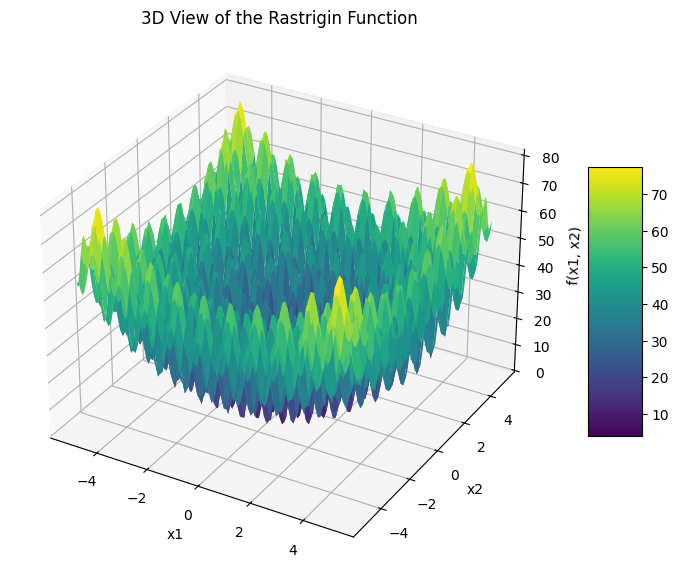

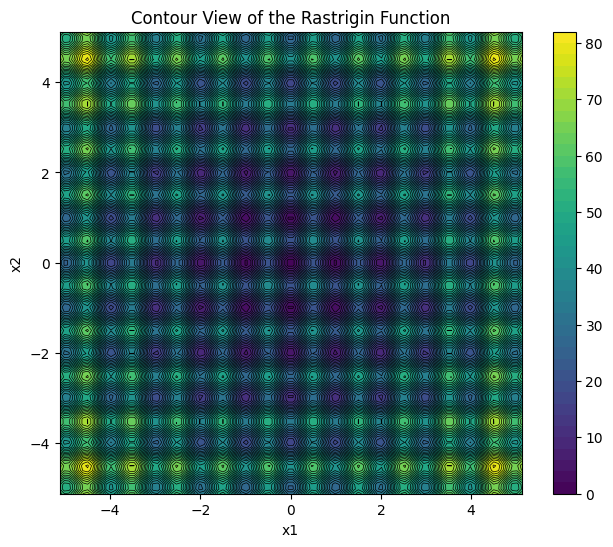


Analysis of the Rastrigin function's shape:
--------------------------------------------
Based on the 3D and contour plots, we can observe the following:
- The function has a distinct global minimum at the center (around x1=0, x2=0).
- Surrounding the global minimum, and throughout the entire plotted area,
  there are many smaller 'dips' and 'hills'.
- These small dips represent local minima, while the hills are local maxima.
- Due to the presence of many local optima, the Rastrigin function is a classic example
  of a MULTIMODAL function.
- Its 'wavy' or 'rugged' landscape makes it challenging for optimization algorithms,
  which can easily get 'stuck' in a local optimum instead of finding the global one.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Definition of the Rastrigin function
def rastrigin_function(x1, x2):
    """
    Computes the value of the Rastrigin function for given x1 and x2.
    f(x1, x2) = 20 + x1^2 + x2^2 - 10*(cos(2*pi*x1) + cos(2*pi*x2))
    """
    term1 = x1**2
    term2 = x2**2
    term3 = 10 * (np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2))
    return 20 + term1 + term2 - term3

# 2. Define the range and generate the grid of points
x_min, x_max = -5.12, 5.12
n_points = 100  # Number of points per axis for plotting

x1_vals = np.linspace(x_min, x_max, n_points)
x2_vals = np.linspace(x_min, x_max, n_points)

# Create a grid of (x1, x2) values
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# 3. Compute the function values Z = f(X1, X2)
Z = rastrigin_function(X1, X2)

# 4. Plot the function

# 4.1. 3D Surface Plot
fig1 = plt.figure(figsize=(10, 7))
ax1 = fig1.add_subplot(111, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none')  # 'viridis' is a popular colormap
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x1, x2)')
ax1.set_title('3D View of the Rastrigin Function')
fig1.colorbar(surf, shrink=0.5, aspect=5)  # Add colorbar
plt.show()

# 4.2. Contour Plot
fig2 = plt.figure(figsize=(8, 6))
ax2 = fig2.add_subplot(111)
contour = ax2.contourf(X1, X2, Z, levels=50, cmap='viridis')  # 'contourf' for filled contours
ax2.contour(X1, X2, Z, levels=50, colors='black', linewidths=0.5)  # Add contour lines
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Contour View of the Rastrigin Function')
ax2.set_aspect('equal', adjustable='box')
fig2.colorbar(contour)  # Add colorbar
plt.show()

# 5. Analysis (textual explanation)
print("\nAnalysis of the Rastrigin function's shape:")
print("--------------------------------------------")
print("Based on the 3D and contour plots, we can observe the following:")
print("- The function has a distinct global minimum at the center (around x1=0, x2=0).")
print("- Surrounding the global minimum, and throughout the entire plotted area,")
print("  there are many smaller 'dips' and 'hills'.")
print("- These small dips represent local minima, while the hills are local maxima.")
print("- Due to the presence of many local optima, the Rastrigin function is a classic example")
print("  of a MULTIMODAL function.")
print("- Its 'wavy' or 'rugged' landscape makes it challenging for optimization algorithms,")
print("  which can easily get 'stuck' in a local optimum instead of finding the global one.")


In [7]:
import numpy as np
import random
from pyeasyga.pyeasyga import GeneticAlgorithm  # Import from the installed library

def rastrigin_function(x):  # Now accepts a list or tuple [x1, x2]
    x1 = x[0]
    x2 = x[1]
    term1 = x1**2
    term2 = x2**2
    term3 = 10 * (np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2))
    return 20 + term1 + term2 - term3

SEARCH_RANGE = [-5.12, 5.12]
BITS_PER_VARIABLE = 3
BINARY_CHROMOSOME_LENGTH = 2 * BITS_PER_VARIABLE

def binary_to_decimal(binary_list):
    decimal_value = 0
    for bit in binary_list:
        decimal_value = (decimal_value << 1) | bit
    return decimal_value

def decode_individual(individual):
    x1_binary = individual[:BITS_PER_VARIABLE]
    x2_binary = individual[BITS_PER_VARIABLE:]
    x1_decimal_raw = binary_to_decimal(x1_binary)
    x2_decimal_raw = binary_to_decimal(x2_binary)
    num_possible_values = 2**BITS_PER_VARIABLE
    x1_decoded = SEARCH_RANGE[0] + \
                 (x1_decimal_raw / (num_possible_values - 1)) * (SEARCH_RANGE[1] - SEARCH_RANGE[0])
    x2_decoded = SEARCH_RANGE[0] + \
                 (x2_decimal_raw / (num_possible_values - 1)) * (SEARCH_RANGE[1] - SEARCH_RANGE[0])
    return [x1_decoded, x2_decoded]

def create_individual(data): 
    return [random.randint(0, 1) for _ in range(BINARY_CHROMOSOME_LENGTH)]

def crossover(parent_1, parent_2):
    if len(parent_1) < 3: 
        idx = random.randrange(1, len(parent_1))
        child_1 = parent_1[:idx] + parent_2[idx:]
        child_2 = parent_2[:idx] + parent_1[idx:]
        return child_1, child_2
    crossover_index1 = random.randrange(1, len(parent_1) - 1) 
    crossover_index2 = random.randrange(crossover_index1 + 1, len(parent_1)) 
    child_1 = parent_1[:crossover_index1] + \
              parent_2[crossover_index1:crossover_index2] + \
              parent_1[crossover_index2:]
    child_2 = parent_2[:crossover_index1] + \
              parent_1[crossover_index1:crossover_index2] + \
              parent_2[crossover_index2:]
    return child_1, child_2

def mutate(individual):
    mutate_index = random.randrange(len(individual))
    individual[mutate_index] = 1 - individual[mutate_index]

def fitness_function(individual, data_function):
    decoded_values = decode_individual(individual)
    return data_function(decoded_values)

# --- Initialization and running GA (first part with 3 bits) ---
ga = GeneticAlgorithm(seed_data=rastrigin_function,
                      population_size=50, generations=100,
                      crossover_probability=0.8, mutation_probability=0.1,
                      elitism=True, maximise_fitness=False)
ga.create_individual = create_individual
ga.crossover_function = crossover
ga.mutate_function = mutate
ga.fitness_function = fitness_function
print(f"Running GA with {BITS_PER_VARIABLE} bits per variable (total {BINARY_CHROMOSOME_LENGTH} bits)...")
ga.run(n_workers=1)  # <--- ADDED n_workers=1

best_fitness, best_individual_genotype = ga.best_individual()
best_individual_phenotype = decode_individual(best_individual_genotype)
print("\n--- Results with {} bits per variable ---".format(BITS_PER_VARIABLE))
print("Best found fitness (Rastrigin function value):", best_fitness)
print("Genotype of best individual (binary):", best_individual_genotype)
print("Phenotype of best individual (decoded x1, x2 values):", best_individual_phenotype)
print("The true global minimum is at (0,0) with f(x1,x2) = 0.")

print("\n" + "="*50 + "\n")

# --- Second part with 10 bits ---
BITS_PER_VARIABLE_MORE = 10
BINARY_CHROMOSOME_LENGTH = 2 * BITS_PER_VARIABLE_MORE  # Update global variable for create_individual
                                                       # and decode_individual if used directly.

ga_more_bits = GeneticAlgorithm(seed_data=rastrigin_function,
                                population_size=50, generations=100,
                                crossover_probability=0.8, mutation_probability=0.02,
                                elitism=True, maximise_fitness=False)
ga_more_bits.create_individual = create_individual 
ga_more_bits.crossover_function = crossover
ga_more_bits.mutate_function = mutate
ga_more_bits.fitness_function = fitness_function
print(f"Running GA with {BITS_PER_VARIABLE_MORE} bits per variable (total {BINARY_CHROMOSOME_LENGTH} bits)...")
ga_more_bits.run(n_workers=1)  # <--- ADDED n_workers=1

best_fitness_more, best_individual_genotype_more = ga_more_bits.best_individual()

# Important: decode_individual uses the global BITS_PER_VARIABLE. We must be careful with this.
# For correct decoding, BITS_PER_VARIABLE must match the genotype being decoded.
original_bits_per_var = BITS_PER_VARIABLE  # Save current value (currently 10)
# decode_individual now uses 10 bits
best_individual_phenotype_more = decode_individual(best_individual_genotype_more)


print("\n--- Results with {} bits per variable ---".format(BITS_PER_VARIABLE_MORE))
print("Best found fitness:", best_fitness_more)
print("Genotype of best individual (binary):", best_individual_genotype_more)
print("Phenotype of best individual (decoded x1, x2 values):", best_individual_phenotype_more)
print("The true global minimum is at (0,0) with f(x1,x2) = 0.")

print("\nAnalysis for Task 1b):")
print("--------------------------")
initial_bits_setting = 3  # Value for the first analysis
print(f"With {initial_bits_setting} bits per variable, each variable can represent only 2^{initial_bits_setting} = {2**initial_bits_setting} values.")
print(f"The range [-5.12, 5.12] is {SEARCH_RANGE[1] - SEARCH_RANGE[0]:.2f} wide.")
print(f"The smallest step (precision) is approximately {(SEARCH_RANGE[1] - SEARCH_RANGE[0]) / (2**initial_bits_setting -1 ):.3f}.")
print(f"With {BITS_PER_VARIABLE_MORE} bits per variable, each variable can represent 2^{BITS_PER_VARIABLE_MORE} = {2**BITS_PER_VARIABLE_MORE} values.")
print(f"The smallest step (precision) is then approximately {(SEARCH_RANGE[1] - SEARCH_RANGE[0]) / (2**BITS_PER_VARIABLE_MORE - 1):.5f}.")

Running GA with 3 bits per variable (total 6 bits)...

--- Results with 3 bits per variable ---
Best found fitness (Rastrigin function value): 22.77063643875411
Genotype of best individual (binary): [0, 1, 0, 0, 1, 0]
Phenotype of best individual (decoded x1, x2 values): [-2.1942857142857144, -2.1942857142857144]
The true global minimum is at (0,0) with f(x1,x2) = 0.


Running GA with 10 bits per variable (total 20 bits)...

--- Results with 10 bits per variable ---
Best found fitness: 22.77063643875411
Genotype of best individual (binary): [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Phenotype of best individual (decoded x1, x2 values): [-2.1942857142857144, -2.1942857142857144]
The true global minimum is at (0,0) with f(x1,x2) = 0.

Analysis for Task 1b):
--------------------------
With 3 bits per variable, each variable can represent only 2^3 = 8 values.
The range [-5.12, 5.12] is 10.24 wide.
The smallest step (precision) is approximately 1.463.
With 10 bits per vari

Testing the impact of mutation_probability (Bits per var: 10, Pop: 50, Gen: 100)

--- Running GA with mutation_probability = 0.0 ---
Best fitness: 5.3051, Solution (x1,x2): [-1.9069, -0.0050]
------------------------------
--- Running GA with mutation_probability = 0.001 ---
Best fitness: 0.4048, Solution (x1,x2): [-0.0050, 0.0450]
------------------------------
--- Running GA with mutation_probability = 0.01 ---
Best fitness: 1.0001, Solution (x1,x2): [-0.0050, -0.9960]
------------------------------
--- Running GA with mutation_probability = 0.05 ---
Best fitness: 0.0099, Solution (x1,x2): [-0.0050, 0.0050]
------------------------------
--- Running GA with mutation_probability = 0.1 ---
Best fitness: 1.0240, Solution (x1,x2): [0.0050, -1.0060]
------------------------------
--- Running GA with mutation_probability = 0.2 ---
Best fitness: 1.2996, Solution (x1,x2): [0.0050, -0.9559]
------------------------------
--- Running GA with mutation_probability = 0.5 ---
Best fitness: 0.0099,

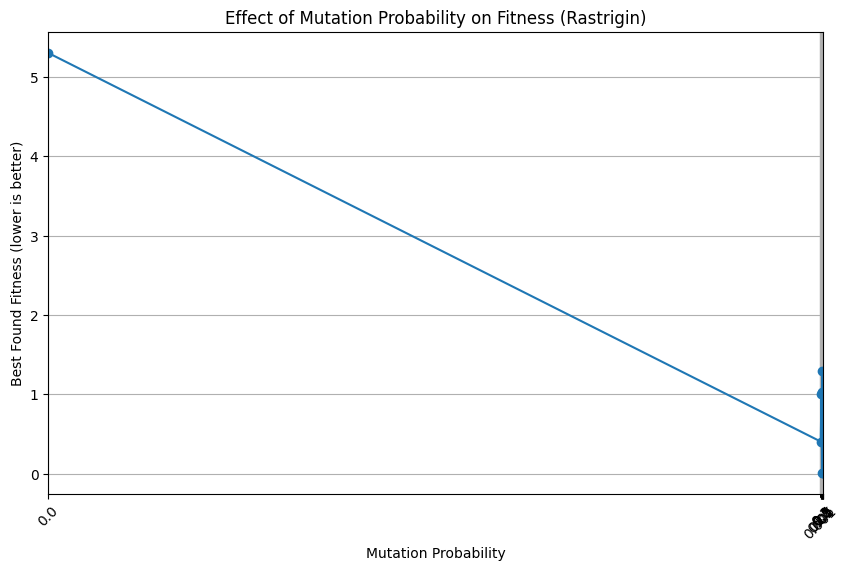

In [10]:
import numpy as np
import random
from pyeasyga.pyeasyga import GeneticAlgorithm
import matplotlib.pyplot as plt  

def rastrigin_function(x):
    x1, x2 = x[0], x[1]
    return 20 + x1**2 + x2**2 - 10 * (np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2))

SEARCH_RANGE = [-5.12, 5.12]

# We use more bits for this experiment to better observe the effects
BITS_PER_VARIABLE = 10  # 10 bits per variable
BINARY_CHROMOSOME_LENGTH = 2 * BITS_PER_VARIABLE

def binary_to_decimal(binary_list):
    decimal_value = 0
    for bit in binary_list:
        decimal_value = (decimal_value << 1) | bit
    return decimal_value

def decode_individual_task_c(individual):
    # individual is a list of 0s and 1s
    # BITS_PER_VARIABLE and SEARCH_RANGE are taken from the global scope
    x1_binary = individual[:BITS_PER_VARIABLE]
    x2_binary = individual[BITS_PER_VARIABLE:]
    x1_decimal_raw = binary_to_decimal(x1_binary)
    x2_decimal_raw = binary_to_decimal(x2_binary)
    num_possible_values = 2**BITS_PER_VARIABLE
    x1_decoded = SEARCH_RANGE[0] + \
                 (x1_decimal_raw / (num_possible_values - 1)) * (SEARCH_RANGE[1] - SEARCH_RANGE[0])
    x2_decoded = SEARCH_RANGE[0] + \
                 (x2_decimal_raw / (num_possible_values - 1)) * (SEARCH_RANGE[1] - SEARCH_RANGE[0])
    return [x1_decoded, x2_decoded]

def create_individual_task_c(data):
    return [random.randint(0, 1) for _ in range(BINARY_CHROMOSOME_LENGTH)]

def crossover_task_c(parent_1, parent_2):
    if len(parent_1) < 3:
        idx = random.randrange(1, len(parent_1))
        child_1 = parent_1[:idx] + parent_2[idx:]
        child_2 = parent_2[:idx] + parent_1[idx:]
        return child_1, child_2
    idx1 = random.randrange(1, len(parent_1) - 1)
    idx2 = random.randrange(idx1 + 1, len(parent_1))
    child_1 = parent_1[:idx1] + parent_2[idx1:idx2] + parent_1[idx2:]
    child_2 = parent_2[:idx1] + parent_1[idx1:idx2] + parent_2[idx2:]
    return child_1, child_2

def mutate_task_c(individual):
    mutate_index = random.randrange(len(individual))
    individual[mutate_index] = 1 - individual[mutate_index]

def fitness_function_task_c(individual, data_function):
    decoded_values = decode_individual_task_c(individual)
    return data_function(decoded_values)

# --- Experiment with different mutation probabilities ---
mutation_probabilities = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 0.9, 1.0]
results = []

# Fixed other GA parameters for this test
POPULATION_SIZE = 50
GENERATIONS = 100  # Might increase if we want better convergence
CROSSOVER_PROBABILITY = 0.8
ELITISM = True

print(f"Testing the impact of mutation_probability (Bits per var: {BITS_PER_VARIABLE}, Pop: {POPULATION_SIZE}, Gen: {GENERATIONS})\n")

for mut_prob in mutation_probabilities:
    print(f"--- Running GA with mutation_probability = {mut_prob} ---")
    ga_mut_test = GeneticAlgorithm(seed_data=rastrigin_function,
                                   population_size=POPULATION_SIZE,
                                   generations=GENERATIONS,
                                   crossover_probability=CROSSOVER_PROBABILITY,
                                   mutation_probability=mut_prob,  
                                   elitism=ELITISM,
                                   maximise_fitness=False)

    ga_mut_test.create_individual = create_individual_task_c
    ga_mut_test.crossover_function = crossover_task_c
    ga_mut_test.mutate_function = mutate_task_c  
    ga_mut_test.fitness_function = fitness_function_task_c
    
    ga_mut_test.run(n_workers=1)  # Disable parallelization

    best_fitness, best_genotype = ga_mut_test.best_individual()
    best_phenotype = decode_individual_task_c(best_genotype)
    
    results.append({
        "mut_prob": mut_prob,
        "fitness": best_fitness,
        "phenotype": best_phenotype,
        "genotype": best_genotype
    })
    print(f"Best fitness: {best_fitness:.4f}, Solution (x1,x2): [{best_phenotype[0]:.4f}, {best_phenotype[1]:.4f}]")
    print("-" * 30)

print("\n--- All results ---")
for res in results:
    print(f"Mut Prob: {res['mut_prob']:.3f} | Fitness: {res['fitness']:.4f} | x1,x2: [{res['phenotype'][0]:.4f}, {res['phenotype'][1]:.4f}]")

# Plotting results (fitness vs mutation_probability)
mut_probs_plot = [res['mut_prob'] for res in results]
fitness_values_plot = [res['fitness'] for res in results]

plt.figure(figsize=(10, 6))
plt.plot(mut_probs_plot, fitness_values_plot, marker='o')
plt.xlabel("Mutation Probability")
plt.ylabel("Best Found Fitness (lower is better)")
plt.title("Effect of Mutation Probability on Fitness (Rastrigin)")
plt.xscale('log')  # Use log scale on x-axis to better see low values
plt.xticks(mutation_probabilities, labels=[str(p) for p in mutation_probabilities], rotation=45)
plt.grid(True, which="both", ls="-")
plt.show()

In [12]:
import numpy as np
import random
from pyeasyga.pyeasyga import GeneticAlgorithm
import matplotlib.pyplot as plt
import time  

# --- Function definitions (same as in 1c) ---
def rastrigin_function(x):
    x1, x2 = x[0], x[1]
    return 20 + x1**2 + x2**2 - 10 * (np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2))

SEARCH_RANGE = [-5.12, 5.12]
BITS_PER_VARIABLE = 10  
BINARY_CHROMOSOME_LENGTH = 2 * BITS_PER_VARIABLE

def binary_to_decimal(binary_list):
    decimal_value = 0
    for bit in binary_list:
        decimal_value = (decimal_value << 1) | bit
    return decimal_value

def decode_individual_task_d(individual):
    x1_binary = individual[:BITS_PER_VARIABLE]
    x2_binary = individual[BITS_PER_VARIABLE:]
    x1_decimal_raw = binary_to_decimal(x1_binary)
    x2_decimal_raw = binary_to_decimal(x2_binary)
    num_possible_values = 2**BITS_PER_VARIABLE
    x1_decoded = SEARCH_RANGE[0] + \
                 (x1_decimal_raw / (num_possible_values - 1)) * (SEARCH_RANGE[1] - SEARCH_RANGE[0])
    x2_decoded = SEARCH_RANGE[0] + \
                 (x2_decimal_raw / (num_possible_values - 1)) * (SEARCH_RANGE[1] - SEARCH_RANGE[0])
    return [x1_decoded, x2_decoded]

def create_individual_task_d(data):
    return [random.randint(0, 1) for _ in range(BINARY_CHROMOSOME_LENGTH)]

def crossover_task_d(parent_1, parent_2):
    if len(parent_1) < 3:
        idx = random.randrange(1, len(parent_1))
        child_1 = parent_1[:idx] + parent_2[idx:]
        child_2 = parent_2[:idx] + parent_1[idx:]
        return child_1, child_2
    idx1 = random.randrange(1, len(parent_1) - 1)
    idx2 = random.randrange(idx1 + 1, len(parent_1))
    child_1 = parent_1[:idx1] + parent_2[idx1:idx2] + parent_1[idx2:]
    child_2 = parent_2[:idx1] + parent_1[idx1:idx2] + parent_2[idx2:]
    return child_1, child_2

def mutate_task_d(individual):
    mutate_index = random.randrange(len(individual))
    individual[mutate_index] = 1 - individual[mutate_index]

def fitness_function_task_d(individual, data_function):
    decoded_values = decode_individual_task_d(individual)
    return data_function(decoded_values)

MUTATION_PROBABILITY = 0.1 
CROSSOVER_PROBABILITY = 0.8
ELITISM = True

configurations = [
    {"pop_size": 20, "gens": 50},    # Small population, few generations
    {"pop_size": 20, "gens": 250},   # Small population, many generations
    {"pop_size": 100, "gens": 50},   # Large population, few generations
    {"pop_size": 100, "gens": 250},  # Large population, many generations
    {"pop_size": 50, "gens": 100}    # Reference from 1c (approximately the same total evaluations as 20x250)
]

results_pop_gen = []

print(f"Testing the impact of population_size and generations (Bits: {BINARY_CHROMOSOME_LENGTH}, MutProb: {MUTATION_PROBABILITY})\n")

for config in configurations:
    pop_s = config["pop_size"]
    gens = config["gens"]
    total_evals = pop_s * gens

    print(f"--- Running GA with PopSize = {pop_s}, Generations = {gens} (Total Evals: {total_evals}) ---")
    start_time = time.time()

    ga_pg_test = GeneticAlgorithm(seed_data=rastrigin_function,
                                  population_size=pop_s,
                                  generations=gens,
                                  crossover_probability=CROSSOVER_PROBABILITY,
                                  mutation_probability=MUTATION_PROBABILITY,
                                  elitism=ELITISM,
                                  maximise_fitness=False)

    ga_pg_test.create_individual = create_individual_task_d
    ga_pg_test.crossover_function = crossover_task_d
    ga_pg_test.mutate_function = mutate_task_d
    ga_pg_test.fitness_function = fitness_function_task_d

    ga_pg_test.run(n_workers=1)

    end_time = time.time()
    duration = end_time - start_time

    best_fitness, best_genotype = ga_pg_test.best_individual()
    best_phenotype = decode_individual_task_d(best_genotype)

    results_pop_gen.append({
        "pop_size": pop_s,
        "gens": gens,
        "total_evals": total_evals,
        "fitness": best_fitness,
        "phenotype": best_phenotype,
        "duration": duration
    })
    print(f"Best fitness: {best_fitness:.4f}, Solution (x1,x2): [{best_phenotype[0]:.4f}, {best_phenotype[1]:.4f}], Time: {duration:.2f}s")
    print("-" * 40)

print("\n--- All results (Population & Generations) ---")
print("PopSize | Gens  | TotalEvals | Fitness | x1,x2                  | Duration(s)")
print("--------|-------|------------|---------|------------------------|-----------")
for res in results_pop_gen:
    print(f"{res['pop_size']:<8}| {res['gens']:<6}| {res['total_evals']:<11}| {res['fitness']:<8.4f}| "
          f"[{res['phenotype'][0]:.4f}, {res['phenotype'][1]:.4f}] | {res['duration']:.2f}")



Testing the impact of population_size and generations (Bits: 20, MutProb: 0.1)

--- Running GA with PopSize = 20, Generations = 50 (Total Evals: 1000) ---
Best fitness: 1.0001, Solution (x1,x2): [0.0050, -0.9960], Time: 0.01s
----------------------------------------
--- Running GA with PopSize = 20, Generations = 250 (Total Evals: 5000) ---
Best fitness: 2.0142, Solution (x1,x2): [-1.0060, -0.9960], Time: 0.06s
----------------------------------------
--- Running GA with PopSize = 100, Generations = 50 (Total Evals: 5000) ---
Best fitness: 2.2898, Solution (x1,x2): [0.9960, -0.9559], Time: 0.06s
----------------------------------------
--- Running GA with PopSize = 100, Generations = 250 (Total Evals: 25000) ---
Best fitness: 0.0099, Solution (x1,x2): [0.0050, -0.0050], Time: 0.32s
----------------------------------------
--- Running GA with PopSize = 50, Generations = 100 (Total Evals: 5000) ---
Best fitness: 1.0001, Solution (x1,x2): [-0.9960, -0.0050], Time: 0.06s
------------------

In [14]:
import numpy as np
import random
from pyeasyga.pyeasyga import GeneticAlgorithm
import time

# --- Function definitions (same as in 1c/1d) ---
def rastrigin_function(x):
    x1, x2 = x[0], x[1]
    return 20 + x1**2 + x2**2 - 10 * (np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2))

SEARCH_RANGE = [-5.12, 5.12]
BITS_PER_VARIABLE = 10  # We use more bits for comparison
BINARY_CHROMOSOME_LENGTH = 2 * BITS_PER_VARIABLE

def binary_to_decimal(binary_list):
    decimal_value = 0
    for bit in binary_list:
        decimal_value = (decimal_value << 1) | bit
    return decimal_value

def decode_individual_task_e(individual):  # New suffix for clarity
    x1_binary = individual[:BITS_PER_VARIABLE]
    x2_binary = individual[BITS_PER_VARIABLE:]
    x1_decimal_raw = binary_to_decimal(x1_binary)
    x2_decimal_raw = binary_to_decimal(x2_binary)
    num_possible_values = 2**BITS_PER_VARIABLE
    x1_decoded = SEARCH_RANGE[0] + \
                 (x1_decimal_raw / (num_possible_values - 1)) * (SEARCH_RANGE[1] - SEARCH_RANGE[0])
    x2_decoded = SEARCH_RANGE[0] + \
                 (x2_decimal_raw / (num_possible_values - 1)) * (SEARCH_RANGE[1] - SEARCH_RANGE[0])
    return [x1_decoded, x2_decoded]

def create_individual_task_e(data):
    return [random.randint(0, 1) for _ in range(BINARY_CHROMOSOME_LENGTH)]

def crossover_task_e(parent_1, parent_2):
    if len(parent_1) < 3:
        idx = random.randrange(1, len(parent_1))
        child_1 = parent_1[:idx] + parent_2[idx:]
        child_2 = parent_2[:idx] + parent_1[idx:]
        return child_1, child_2
    idx1 = random.randrange(1, len(parent_1) - 1)
    idx2 = random.randrange(idx1 + 1, len(parent_1))
    child_1 = parent_1[:idx1] + parent_2[idx1:idx2] + parent_1[idx2:]
    child_2 = parent_2[:idx1] + parent_1[idx1:idx2] + parent_2[idx2:]
    return child_1, child_2

def mutate_task_e(individual):
    mutate_index = random.randrange(len(individual))
    individual[mutate_index] = 1 - individual[mutate_index]

def fitness_function_task_e(individual, data_function):
    decoded_values = decode_individual_task_e(individual)
    return data_function(decoded_values)

# --- Experiment with population_size = 5 and elitism = False ---
POP_SIZE_EXTREME = 5
ELITISM_OFF = False
GENERATIONS_E = 100  # Fixed number of generations, e.g. 100
MUTATION_PROB_E = 0.1  # Use a moderate mutation rate
CROSSOVER_PROB_E = 0.8

print(f"Testing with PopSize = {POP_SIZE_EXTREME}, Elitism = {ELITISM_OFF} (Bits: {BINARY_CHROMOSOME_LENGTH}, Gens: {GENERATIONS_E}, MutProb: {MUTATION_PROB_E})\n")
start_time = time.time()

ga_extreme_test = GeneticAlgorithm(seed_data=rastrigin_function,
                                   population_size=POP_SIZE_EXTREME,
                                   generations=GENERATIONS_E,
                                   crossover_probability=CROSSOVER_PROB_E,
                                   mutation_probability=MUTATION_PROB_E,
                                   elitism=ELITISM_OFF,  # ELITISM DISABLED
                                   maximise_fitness=False)

ga_extreme_test.create_individual = create_individual_task_e
ga_extreme_test.crossover_function = crossover_task_e
ga_extreme_test.mutate_function = mutate_task_e
ga_extreme_test.fitness_function = fitness_function_task_e

ga_extreme_test.run(n_workers=1)

end_time = time.time()
duration = end_time - start_time

best_fitness, best_genotype = ga_extreme_test.best_individual()
best_phenotype = decode_individual_task_e(best_genotype)

print(f"--- Results with PopSize = {POP_SIZE_EXTREME}, Elitism = {ELITISM_OFF} ---")
print(f"Best fitness: {best_fitness:.4f}")
print(f"Solution (x1,x2): [{best_phenotype[0]:.4f}, {best_phenotype[1]:.4f}]")
print(f"Execution time: {duration:.2f}s")
print("The actual global minimum is at (0,0) with f(x1,x2) = 0.")

Testing with PopSize = 5, Elitism = False (Bits: 20, Gens: 100, MutProb: 0.1)

--- Results with PopSize = 5, Elitism = False ---
Best fitness: 4.1299
Solution (x1,x2): [-2.0170, -0.0050]
Execution time: 0.01s
The actual global minimum is at (0,0) with f(x1,x2) = 0.


In [15]:
import numpy as np
import random
from pyeasyga.pyeasyga import GeneticAlgorithm
import time
import matplotlib.pyplot as plt 

def rastrigin_function(x):
    x1, x2 = x[0], x[1]
    return 20 + x1**2 + x2**2 - 10 * (np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2))

SEARCH_RANGE = [-5.12, 5.12]
BITS_PER_VARIABLE = 10
BINARY_CHROMOSOME_LENGTH = 2 * BITS_PER_VARIABLE

def binary_to_decimal(binary_list):
    decimal_value = 0
    for bit in binary_list:
        decimal_value = (decimal_value << 1) | bit
    return decimal_value

def decode_individual_task_f(individual):
    x1_binary = individual[:BITS_PER_VARIABLE]
    x2_binary = individual[BITS_PER_VARIABLE:]
    x1_decimal_raw = binary_to_decimal(x1_binary)
    x2_decimal_raw = binary_to_decimal(x2_binary)
    num_possible_values = 2**BITS_PER_VARIABLE
    x1_decoded = SEARCH_RANGE[0] + \
                 (x1_decimal_raw / (num_possible_values - 1)) * (SEARCH_RANGE[1] - SEARCH_RANGE[0])
    x2_decoded = SEARCH_RANGE[0] + \
                 (x2_decimal_raw / (num_possible_values - 1)) * (SEARCH_RANGE[1] - SEARCH_RANGE[0])
    return [x1_decoded, x2_decoded]

def create_individual_task_f(data):
    return [random.randint(0, 1) for _ in range(BINARY_CHROMOSOME_LENGTH)]

def crossover_task_f(parent_1, parent_2):
    if len(parent_1) < 3:
        idx = random.randrange(1, len(parent_1))
        child_1 = parent_1[:idx] + parent_2[idx:]
        child_2 = parent_2[:idx] + parent_1[idx:]
        return child_1, child_2
    idx1 = random.randrange(1, len(parent_1) - 1)
    idx2 = random.randrange(idx1 + 1, len(parent_1))
    child_1 = parent_1[:idx1] + parent_2[idx1:idx2] + parent_1[idx2:]
    child_2 = parent_2[:idx1] + parent_1[idx1:idx2] + parent_2[idx2:]
    return child_1, child_2

def mutate_task_f(individual):
    mutate_index = random.randrange(len(individual))
    individual[mutate_index] = 1 - individual[mutate_index]

def fitness_function_task_f(individual, data_function):
    decoded_values = decode_individual_task_f(individual)
    return data_function(decoded_values)

# --- Implementation of Roulette Wheel Selection ---
def roulette_wheel_selection(population):
    """Selects one individual from the population using the roulette wheel principle."""

    fitness_values = [individual.fitness for individual in population]
    
    if not fitness_values: # If the population is empty
        return None

    max_f = max(fitness_values) if fitness_values else 0
    epsilon = 1e-6 # Small constant

    selection_scores = [(max_f - f) + epsilon for f in fitness_values]
    total_selection_score = sum(selection_scores)

    if total_selection_score == 0:
        # If all selection_scores are 0 (e.g., all fitnesses equal max_f),
        # pick randomly to avoid division by zero.
        return random.choice(population)

    pick = random.uniform(0, total_selection_score)
    current_sum = 0
    for individual in population:
        original_fitness = individual.fitness
        score = (max_f - original_fitness) + epsilon
        
        current_sum += score
        if current_sum >= pick:
            return individual

    return random.choice(population)


# --- Experiment ---
POP_SIZE = 50
GENERATIONS = 100
MUTATION_PROB = 0.1 
CROSSOVER_PROB = 0.8
ELITISM = True 

print(f"Testing with Roulette Wheel Selection (Bits: {BINARY_CHROMOSOME_LENGTH}, Pop: {POP_SIZE}, Gens: {GENERATIONS}, MutProb: {MUTATION_PROB})\n")
start_time_roulette = time.time()

ga_roulette = GeneticAlgorithm(seed_data=rastrigin_function,
                               population_size=POP_SIZE,
                               generations=GENERATIONS,
                               crossover_probability=CROSSOVER_PROB,
                               mutation_probability=MUTATION_PROB,
                               elitism=ELITISM,
                               maximise_fitness=False)

ga_roulette.create_individual = create_individual_task_f
ga_roulette.crossover_function = crossover_task_f
ga_roulette.mutate_function = mutate_task_f
ga_roulette.fitness_function = fitness_function_task_f
ga_roulette.selection_function = roulette_wheel_selection 

ga_roulette.run(n_workers=1)

end_time_roulette = time.time()
duration_roulette = end_time_roulette - start_time_roulette

best_fitness_r, best_genotype_r = ga_roulette.best_individual()
best_phenotype_r = decode_individual_task_f(best_genotype_r)

print(f"--- Results with Roulette Wheel Selection ---")
print(f"Best fitness: {best_fitness_r:.4f}")
print(f"Solution (x1,x2): [{best_phenotype_r[0]:.4f}, {best_phenotype_r[1]:.4f}]")
print(f"Execution time: {duration_roulette:.2f}s")

print("\nTesting with Tournament Selection (default)...")
start_time_tournament = time.time()

ga_tournament = GeneticAlgorithm(seed_data=rastrigin_function,
                                 population_size=POP_SIZE,
                                 generations=GENERATIONS,
                                 crossover_probability=CROSSOVER_PROB,
                                 mutation_probability=MUTATION_PROB,
                                 elitism=ELITISM,
                                 maximise_fitness=False)

ga_tournament.create_individual = create_individual_task_f
ga_tournament.crossover_function = crossover_task_f
ga_tournament.mutate_function = mutate_task_f
ga_tournament.fitness_function = fitness_function_task_f

ga_tournament.run(n_workers=1)

end_time_tournament = time.time()
duration_tournament = end_time_tournament - start_time_tournament

best_fitness_t, best_genotype_t = ga_tournament.best_individual()
best_phenotype_t = decode_individual_task_f(best_genotype_t)

print(f"--- Results with Tournament Selection ---")
print(f"Best fitness: {best_fitness_t:.4f}")
print(f"Solution (x1,x2): [{best_phenotype_t[0]:.4f}, {best_phenotype_t[1]:.4f}]")
print(f"Execution time: {duration_tournament:.2f}s")

Testing with Roulette Wheel Selection (Bits: 20, Pop: 50, Gens: 100, MutProb: 0.1)

--- Results with Roulette Wheel Selection ---
Best fitness: 1.2996
Solution (x1,x2): [-0.9559, -0.0050]
Execution time: 0.10s

Testing with Tournament Selection (default)...
--- Results with Tournament Selection ---
Best fitness: 0.0099
Solution (x1,x2): [-0.0050, -0.0050]
Execution time: 0.06s


# Exercise 2

In [ ]:
import random
from pyeasyga import pyeasyga

seed_data = [0, 1, 2, 3, 4, 5, 6, 7]

ga = pyeasyga.GeneticAlgorithm(seed_data,
                               population_size=200,
                               generations=100,
                               crossover_probability=0.8,
                               mutation_probability=0.2,
                               elitism=True,
                               maximise_fitness=False)

def create_individual(data):
    individual = data[:]
    random.shuffle(individual)
    return individual

ga.create_individual = create_individual

def crossover(parent_1, parent_2):
    crossover_index = random.randrange(1, len(parent_1))
    child_1a = parent_1[:crossover_index]
    child_1b = [i for i in parent_2 if i not in child_1a]
    child_1 = child_1a + child_1b

    child_2a = parent_2[crossover_index:]
    child_2b = [i for i in parent_1 if i not in child_2a]
    child_2 = child_2b + child_2a

    return child_1, child_2

ga.crossover_function = crossover

def mutate(individual):
    i, j = random.sample(range(len(individual)), 2)
    individual[i], individual[j] = individual[j], individual[i]

ga.mutate_function = mutate

def selection(population):
    return random.choice(population)

ga.selection_function = selection

def fitness(individual, data):
    collisions = 0
    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):
            if abs(individual[i] - individual[j]) == abs(i - j):
                collisions += 1
    return collisions

ga.fitness_function = fitness
ga.run()

def print_board(board):
    n = len(board)
    for row in range(n):
        line = "|"
        for col in range(n):
            line += " X |" if board[row] == col else "   |"
        print("-" * (n * 4))
        print(line)
    print("-" * (n * 4))

best_fitness, best_solution = ga.best_individual()
if best_fitness == 0:
    print("Best solution (no collisions):", best_solution)
    print_board(best_solution)
else:
    print("No valid solution found.")

## Task 2 - Analysis of the 8 Queens Problem Example with `pyeasyga`

### (a) How is the encoding mechanism defined?

The encoding mechanism used in this example for the 8 Queens problem is **permutation encoding**.

*   **Genotype (Chromosome Representation):** An individual (a potential arrangement of queens) is represented as a **list of 8 unique integers, specifically a permutation of the numbers 0 through 7.**
    *   This is evident from the `seed_data` and the `create_individual` function:
        ```python
        seed_data = [0, 1, 2, 3, 4, 5, 6, 7]

        def create_individual(data):
            individual = data[:]  # Creates a copy of seed_data
            random.shuffle(individual)  # Randomly shuffles the elements
            return individual
        ```
    *   Each chromosome will thus be a list like `[3, 1, 6, 2, 5, 7, 0, 4]`.

*   **Interpretation (Phenotype):**
    *   The **index** of an element in the list represents the **column** on the chessboard (from 0 to 7).
    *   The **value** of the element at that index represents the **row** (from 0 to 7) in which the queen in that column is placed.
    *   For example, if the chromosome is `[3, 1, 6, 2, 5, 7, 0, 4]`:
        *   The queen in column 0 is in row 3.
        *   The queen in column 1 is in row 1.
        *   The queen in column 2 is in row 6.
        *   ...and so on.

*   **Advantages of this Encoding:**
    *   **Implicit Constraint Satisfaction:** This encoding inherently satisfies two of the main constraints of the 8 Queens problem:
        1.  **No two queens in the same column:** Because each position (index) in the list uniquely corresponds to a column, and there's only one value (queen) per position.
        2.  **No two queens in the same row:** Because the list is a permutation of unique numbers (0-7), each row number appears exactly once, meaning each queen is in a unique row.
    *   **Reduced Search Space:** By satisfying these constraints directly through encoding, the genetic algorithm only needs to search for solutions that avoid diagonal attacks. The fitness function can then focus solely on penalizing (or counting) diagonal collisions.

This permutation encoding is a common and effective way to represent solutions for the N-Queens problem.

### (b) How is the selection mechanism defined?

The selection mechanism in this `pyeasyga` example is explicitly defined by assigning a custom function to `ga.selection_function`:

```python
# define and set the GA's selection operation
def selection(population):
    return random.choice(population)

ga.selection_function = selection
```

#### Type of Selection:
The implemented selection function performs **Random Selection**.

#### How it Works:
For each selection event (i.e., each time a parent needs to be chosen to contribute to the next generation), this function simply picks an individual randomly from the current population.  
Every individual in the population has an equal probability of being selected, regardless of its fitness score.

#### Implications:

- **No Selection Pressure**:  
  This method does not exert any selection pressure towards fitter individuals. "Good" and "bad" solutions (in terms of fitness) have the same chance of becoming parents.

- **Exploration vs. Exploitation**:  
  Random selection promotes exploration of the search space (as it doesn't discard any part of the population prematurely) but does very little for exploitation (focusing on and refining good solutions).

- **Convergence**:  
  Convergence towards an optimal solution is likely to be very slow, or the algorithm might not converge to a good solution at all, as there's no mechanism to preferentially propagate the traits of better-performing individuals. The search becomes largely random, relying heavily on crossover and mutation to stumble upon good solutions.

#### Default Behavior (if not set):
It's worth noting that if `ga.selection_function` were not explicitly set, `pyeasyga` would use its default selection mechanism, which is **Tournament Selection**.  
The authors of this example have specifically chosen to override the default with this very basic random selection — perhaps for simplicity or demonstration purposes.

### (c) How is the fitness function defined?

The fitness function is defined to evaluate the "goodness" of a given arrangement of queens (an `individual`). In the context of the 8 Queens problem, a better solution is one with fewer queens attacking each other.

The fitness function is implemented as follows:

```python
# define a fitness function
def fitness(individual, data):  # 'data' is the seed_data, not used in this fitness calculation
    collisions = 0
    # Iterate through each queen (represented by its row position in a specific column)
    for i in range(len(individual)):
        # Compare it with every other queen to its right to avoid double counting pairs
        for j in range(i + 1, len(individual)):
            # 'individual[i]' is the row of the queen in column 'i'
            # 'individual[j]' is the row of the queen in column 'j'
            # Check for diagonal attacks:
            # Two queens (col1, row1) and (col2, row2) are on the same diagonal
            # if the absolute difference in their rows equals the absolute difference in their columns.
            # Here, col1 is 'i', row1 is 'individual[i]'
            # And col2 is 'j', row2 is 'individual[j]'
            # So, the condition is: abs(individual[i] - individual[j]) == abs(i - j)
            if abs(individual[i] - individual[j]) == abs(i - j):
                collisions += 1
    return collisions

ga.fitness_function = fitness  # set the GA's fitness function
```

#### Objective:
The function aims to count the number of pairs of queens that are attacking each other diagonally.  
Horizontal and vertical attacks are inherently prevented by the permutation encoding (one queen per row, one queen per column).

#### Calculation:

- It initializes a `collisions` counter to 0.
- It uses nested loops to consider every unique pair of queens. The outer loop iterates from `i = 0` to `n-1` (where `n` is the number of queens, 8 in this case), and the inner loop iterates from `j = i + 1` to `n-1`.  
  This `j = i + 1` ensures that each pair is checked only once, preventing double-counting of collisions.
- For each pair of queens (one in column `i` at row `individual[i]`, and another in column `j` at row `individual[j]`), it checks if they are on the same diagonal.
- The condition `abs(individual[i] - individual[j]) == abs(i - j)` is the mathematical check for two points `(i, individual[i])` and `(j, individual[j])` lying on the same diagonal.
- If they are on the same diagonal, the `collisions` counter is incremented.

#### Return Value:
The function returns the total number of diagonal collisions.

#### Minimization or Maximization:
The `GeneticAlgorithm` instance was initialized with `maximise_fitness=False`:

```python
ga = pyeasyga.GeneticAlgorithm(..., maximise_fitness=False)
```

This tells `pyeasyga` that the goal is to **minimize** the value returned by the fitness function. Therefore, a **lower number of collisions** (a lower fitness score) is better.

#### Ideal Fitness:
An ideal solution (a valid 8 Queens arrangement) will have a **fitness score of 0**, indicating **no diagonal collisions**.  
This fitness function directly measures the "badness" of a solution (number of attacking pairs), and the GA's goal is to drive this measure down to zero.

### (d) How is the crossover operator defined?

The crossover operator is custom-defined and assigned to `ga.crossover_function`. It's tailored to work with the permutation encoding used in the N-Queens problem, ensuring that offspring are valid permutations.

```python
# define and set the GA's crossover operation
def crossover(parent_1, parent_2):
    crossover_index = random.randrange(1, len(parent_1))  # Choose a single crossover point

    # Create the first child
    child_1a = parent_1[:crossover_index]
    child_1b = [i for i in parent_2 if i not in child_1a]
    child_1 = child_1a + child_1b

    # Create the second child (as implemented in the provided code)
    child_2a = parent_2[crossover_index:]
    child_2b = [i for i in parent_1 if i not in child_2a]
    child_2 = child_2b + child_2a

    return child_1, child_2

ga.crossover_function = crossover
```

#### Type of Crossover

This operator is a variation of Order Crossover (OX1) or a Partially Mapped Crossover (PMX)-like mechanism, specifically tailored for permutations. It's essentially a single-point crossover adapted to maintain the permutation property.

- **For `child_1`:**  
  It takes a prefix from `parent_1`. The remaining elements are taken from `parent_2` in their original relative order, skipping any elements already present from `parent_1`'s prefix. This is characteristic of Order Crossover.

- **For `child_2`** (as implemented in your provided code: `child_2 = child_2b + child_2a`):  
  - `child_2a` takes the suffix (tail end) of `parent_2` starting from `crossover_index`.  
  - `child_2b` takes elements from `parent_1` that are not in `child_2a`, preserving their order from `parent_1`.  
  - `child_2` is formed by concatenating `child_2b` (elements from `parent_1`) followed by `child_2a` (suffix from `parent_2`). This is a valid way to create a new permutation but differs slightly from a perfectly symmetrical OX1 or a classic PMX for the second child. The key is that it produces a valid permutation.

---

#### How it Works:

1. A single `crossover_index` is randomly chosen (this index will be between the first and last element).

2. **For `child_1`:**  
   - The segment of `parent_1` from the beginning up to (but not including) `crossover_index` is copied directly to `child_1`.  
   - The remaining positions in `child_1` are filled with elements from `parent_2`, taken in the order they appear in `parent_2`, provided they are not already in the copied segment from `parent_1`.

3. **For `child_2`**:  
   - The segment of `parent_2` from `crossover_index` to the end is taken (`child_2a`).  
   - Elements from `parent_1` that are not in `child_2a` are selected, maintaining their relative order (`child_2b`).  
   - `child_2` is formed by putting `child_2b` first, then `child_2a`.

### (e) How is the mutation operator defined?

The mutation operator is custom-defined and assigned to `ga.mutate_function`. It is designed to work with the permutation encoding by altering an individual (chromosome) slightly while ensuring it remains a valid permutation.

```python
# define and set the GA's mutation operation
def mutate(individual):
    # Randomly select two distinct indices i and j from the range of the individual's length
    i, j = random.sample(range(len(individual)), 2)
    # Swap the elements at these two indices
    individual[i], individual[j] = individual[j], individual[i]

ga.mutate_function = mutate

### Type of Mutation:
This is a Swap Mutation (also known as Exchange Mutation or Reciprocal Exchange Mutation).

### How it Works:
`i, j = random.sample(range(len(individual)), 2)`: This line randomly selects two distinct indices `i` and `j` from the valid range of indices for the individual (chromosome). `random.sample(population, k)` returns a `k` length list of unique elements chosen from the population sequence. Here, `population` is `range(len(individual))` and `k` is `2`.

`individual[i], individual[j] = individual[j], individual[i]`: The elements (queen row positions) at these two randomly chosen indices (columns) are then swapped.

### Example:
If `individual = [0, 1, 2, 3, 4, 5, 6, 7]`  
And `random.sample` chooses `i = 2` and `j = 5`.  
The element at index `2` is `2` (queen in column 2 is in row 2).  
The element at index `5` is `5` (queen in column 5 is in row 5).  
After the swap: `individual[2]` becomes `5`, and `individual[5]` becomes `2`.  
The mutated individual becomes `[0, 1, 5, 3, 4, 2, 6, 7]`.

### Ensuring Validity:
Swap mutation is well-suited for permutation encodings because swapping two elements in a permutation always results in another valid permutation. All original elements are still present, just in a different order.

### Role in GA:
- This mutation introduces small, localized changes to a solution.
- It helps maintain genetic diversity in the population.
- It allows the GA to explore areas of the search space that might not be reachable through crossover alone, potentially helping it to escape local optima.

### `mutation_probability`:
The `mutation_probability` parameter set in the `GeneticAlgorithm` constructor (e.g., `mutation_probability=0.2`) determines the chance that this `mutate` function will be called for any given individual after it has been created or has undergone crossover. If the "dice roll" for mutation is successful for an individual, then this `mutate` function is executed, performing one swap.

This swap mutation is a common and effective mutation operator for permutation-based GAs like the one used for the N-Queens problem.

### (f) What changes would need to be made to solve the generalized N-Queens problem?

To adapt the provided 8-Queens `pyeasyga` example to solve the generalized N-Queens problem (for an N×N board with N queens), the following modifications would be necessary:

1.  **Parameterize Board Size (N):**
    *   Introduce a variable, let's call it `N_QUEENS`, at the beginning of the script, which will define the size of the board and the number of queens.
        ```python
        N_QUEENS = 4  # Example for a 4x4 board
        # N_QUEENS = 10 # Example for a 10x10 board
        ```

2.  **Adapt `seed_data`:**
    *   The `seed_data`, which is used as a template for creating individuals, must be generated based on `N_QUEENS`.
        ```python
        seed_data = list(range(N_QUEENS)) # Will be [0, 1, 2, ..., N_QUEENS-1]
        ```

3.  **Adapt `create_individual` function:**
    *   This function already uses `data[:]` (which would be `seed_data`) and `random.shuffle()`. As long as `seed_data` is correctly initialized based on `N_QUEENS`, this function should work without changes to its internal logic, as it shuffles the provided data. The length of the `individual` created will automatically correspond to `N_QUEENS`.

4.  **Adapt `crossover` function:**
    *   The core logic of the provided crossover (taking segments and filling with remaining unique elements) is generally applicable to permutations of any length.
    *   The `random.randrange(1, len(parent_1))` will correctly adapt to the length of the parents, which will be `N_QUEENS`. No direct changes to the crossover logic itself are strictly necessary, assuming `parent_1` and `parent_2` are correctly sized based on `N_QUEENS`.

5.  **Adapt `mutate` function:**
    *   The swap mutation `random.sample(range(len(individual)), 2)` will also correctly adapt, as `len(individual)` will be `N_QUEENS`. It will pick two random distinct indices within the range `0` to `N_QUEENS-1`.

6.  **Adapt `fitness` function:**
    *   The core logic for checking diagonal collisions, `abs(individual[i] - individual[j]) == abs(i - j)`, is independent of the board size N.
    *   The loops `for i in range(len(individual))` and `for j in range(i + 1, len(individual))` will automatically iterate correctly based on the length of the `individual`, which is `N_QUEENS`. So, the fitness function logic should largely remain the same.

8.  **Adjust GA Parameters:**
    *   **`population_size`**: For larger N, the search space grows significantly. A larger population size might be beneficial to maintain diversity and explore more effectively.
    *   **`generations`**: Similarly, more generations might be needed for larger N to allow the algorithm sufficient time to converge to a good solution.
    *   `mutation_probability` and `crossover_probability`: These might also need fine-tuning for different values of N, but the existing values could serve as a starting point.

The permutation encoding and the chosen genetic operators (order-based crossover, swap mutation) are quite scalable for the N-Queens problem. The main challenge for larger N becomes the increased size of the search space, which might require more computational effort (larger populations, more generations) for the GA to find a solution.